## Intro

This is the second article I've written about teaching computers to play Snake. The plan for this article is to address some of the limiltation of my first version, and explore Deep Q Learning as an alternative.

## Deep Q Learning Overview

Recall that the Q function from normal Q learning maps each possible state of the task you are trying to solve, along with each possible action, to a "Q value" which dictates the effectiveness of taking that action. This approach works for small games and tasks where there are few states and actions, but even moderately sized tasks, such as the 10x10 snake game we are using for this article, are too big to efficiently store in memory. Another issue arises when our task has a "continuous" state, for example Cartpole, a simple reinforcement learning problem where we teach an agent to move a cart to balance a pole. Here, the angle of the pole depends on gravity and its previous angle, neither of which are discrete values. It therefore isn't optimal to use regular Q learning, because any (state, action) table would need to have infinite keys to represent the whole system.

Deep Q learning (DQN) replaces the Q function from normal Q learning with a neural network. This fixes problems with large tables and discrete values in 1 go. In DQN, the neural network takes in a state and outputs scores for all actions simultaneously, such that you can pick the action with the highest score (just as in normal Q learning). It's not as simple as applying the nueral network to the state and getting the best move though (at least not in training), because the network needs to learn intuition for what the best move could be, and it can't do that without us giving it a picture of the consequences of its moves. Instead, we save a buffer (current state, action, reward, next state) which gives the full picture of whether a move was good or bad.
- current state: initial state the network examines
- action: action taken by the network (or random action, as we will see below)
- reward: how good the action was given the previous state
- next state: result of the action

This is known as experience replay. We train our neural network by sampling mini-batches from the replay buffer so the network can learn from scenarios it has already seen, and prevent overfitting so that the same sequences are not replayed over and over.

There's one part of the above explanation that may not click just yet. We have a list of game states and the respective action the network took. But there's no guarantee that the action in our data is the _best_ one for that state. So if we train a neural network normally on these, it will learn... nothing. This leads to a problem: how do we define the "correct action" for a state? 

We may not necessarily know the best move at a state, and in theory to discover it we would need to play the game optimally ourselves. But the whole point is to teach the model to do it without necessarily knowing what the optimal move for every state ourselves (for snake it's pretty obvious to a human, but in general it may not be). This is where DQN becomes less intuitive, as it doesn't learn what the best move is, instead, it learns to assign a numerical value to the consequence of each move it can take. Think of chess grandmasters, who frequently describe having seen 10-20 moves ahead. In a way, they have both memory and an "internal Q function" which they use to rate their positions. They then pick the move with the best consequences. We want our neural network to build that "intuition", and as such figure out _which actions were good and which were not based on the consequences of said action_, not what the best action was. The best action will naturally follow.

The full algorithm is described below.

In [21]:
from random import choice, shuffle, uniform, randint, sample
import torch
from collections import namedtuple, Counter, deque
import copy
from tqdm import tqdm
import numpy as np
from matplotlib import pyplot as plt
from abc import ABC, abstractmethod

## Game Definition

The game definition is pretty simple, just an implementation of snake. I do want to point out a few caveats which will make this implementation usable by an agent:
- rather than containing its own game loop, the game has the `execute_action` function, which executes a single step of the game. This allows the caller to control the game loop, making this implementation useful for training and testing.
- there are two abstract methods: `_get_reward` and `get_current_state`, which define the state and reward respectively. These are the attributes that we can vary between our different implementations, which be crucial in optimizing each version of our DQN algorithm.
- in the action execution, there's a stop criterion to prevent infinite loops: if the agent goes $2n$ steps without getting an apple (for board size $n$), the game resets.

In [22]:
Point = namedtuple('Point', ['x', 'y'])
GameStep = namedtuple('GameStep', ['current_state', 'action', 'reward', 'next_state'])


class SnakeGame(ABC):
    ACTIONS = ((0, -1), (-1, 0), (0, 1), (1, 0))

    def __init__(self, n: int):
        self.n = n
        self.max_steps = 2 * n
        self.num_games = 0
        self.total_length = 0
        self.total_apples_eaten = 0
        self.game_length = 0
        self.num_apples_eaten = 0
        self.prev_action = None
        self.max_game_len = 0
        self.max_apples_eaten = 0
        self._initialize_game()
    
    def _get_next_apple(self) -> Point:
        return self.all_apples.pop(0)
    
    def _get_valid_starting_spaces(self) -> tuple[list[int], list[int]]:
        return (
            [*range(1, self.apple.x - 1), *range(self.apple.x + 1, self.n - 1)], 
            [*range(1, self.apple.y - 1), *range(self.apple.y + 1, self.n - 1)]
        )
    
    def _get_valid_snake_addition(self) -> Point:
        tail = self.snake[-1]
        for point in [Point(tail.x + dx, tail.y + dy) for (dx, dy) in self.ACTIONS]:
            if self.grid[point.x][point.y] == 0:
                return point

    def _initialize_game(self):
        self.all_apples: list[Point] = [Point(x, y) for x in range(1, self.n - 1) for y in range(1, self.n - 1)]

        shuffle(self.all_apples)

        self.grid: list[list[int]] = [[-1 for _ in range(self.n)]] + \
            [[-1] + [0 for _ in range(self.n - 2)] + [-1] for _ in range(self.n - 2)] + \
            [[-1 for _ in range(self.n)]]
        
        self.apple: Point = self._get_next_apple()

        valid_starting_spaces: list[Point] = self._get_valid_starting_spaces()

        self.snake: list[Point] = [Point(choice(valid_starting_spaces[0]), choice(valid_starting_spaces[1]))]

        self.grid[self.apple.x][self.apple.y] = 1
        self.grid[self.snake[0].x][self.snake[0].y] = -1

        self.max_game_len = max(self.max_game_len, self.game_length)
        self.max_apples_eaten = max(self.max_apples_eaten, self.num_apples_eaten)

        self.steps = 0
        self.game_length = 0
        self.total_apples_eaten += self.num_apples_eaten
        self.num_apples_eaten = 0
        self.num_games += 1
    
    @abstractmethod
    def _get_reward(self, current_state, action: int, **kwargs) -> int:
        pass
    
    def _determine_corner(self, i: int):
        if i == 0 or i == len(self.snake) - 1:
            return False
        pre = self.snake[i - 1]
        post = self.snake[i + 1]
        x1d = self.snake[i].x - pre[0]
        x2d = post[0] - self.snake[i].x
        y1d = self.snake[i].y - pre[1]
        y2d = post[1] - self.snake[i].y
        return x1d != x2d or y1d != y2d

    def _pretty_print_grid(self):
        snake_count = 0
        print("abhij2706.github.io:frame#start")
        for i, y in enumerate(self.grid, 0):
            for j, xy in enumerate(y, 0):
                if i == 0 or i == self.n - 1:
                    print("⬜️", end="")
                elif j == 0 or j == self.n - 1:
                    print("⬜️", end="")
                elif xy == -1 and i == self.snake[0].x and j == self.snake[0].y:
                    print("✅", end="")
                elif xy == 1:
                    print("🔴", end="")
                elif xy == -1:
                    snake_count = 0
                    for l, k in enumerate(self.snake, 0):
                        if i == k.x and j == k.y:
                            snake_count = l
                            break
                    print("🟢" if self._determine_corner(snake_count) else "🟩", end="")
                else:
                    print(f"⬛️", end="")
            print()
        print("abhij2706.github.io:frame#end")
    
    def reset_aggregate_analytics(self):
        self.num_games = 0
        self.total_length = 0
        self.total_apples_eaten = 0
        self.max_apples_eaten = 0
        self.max_game_len = 0

    @abstractmethod
    def get_current_state(self):
        pass

    def execute_action(self, action: int) -> GameStep:
        current_state = self.get_current_state()
        new_snake_head = Point(
            self.snake[0].x + self.ACTIONS[action][0], 
            self.snake[0].y + self.ACTIONS[action][1], 
        )
        self.steps += 1
        self.game_length += 1
        if self.steps >= self.max_steps:
            reward = self._get_reward(current_state, action, steps_exceeded=True)
            self.total_length += self.game_length
            self._initialize_game()
            new_snake_head = self.snake[0]
        if self.grid[new_snake_head.x][new_snake_head.y] == -1: # death
            reward = self._get_reward(current_state, action, death=True)
            self.total_length += self.game_length
            self._initialize_game()
            new_snake_head = self.snake[0]
        elif self.grid[new_snake_head.x][new_snake_head.y] == 1: # apple
            self.num_apples_eaten += 1
            reward = self._get_reward(current_state, action, apple=True)
            self.apple = self._get_next_apple()
            while self.grid[self.apple.x][self.apple.y] != 0:
                self.all_apples.append(self.apple)
                self.apple = self._get_next_apple()
            new_tail = self._get_valid_snake_addition()
            self.snake.append(new_tail)
            self.steps = 0
        else:
            reward = self._get_reward(current_state, action)

        self.grid[self.apple.x][self.apple.y] = 1
        self.grid[new_snake_head.x][new_snake_head.y] = -1
        self.grid[self.snake[-1].x][self.snake[-1].y] = 0
        self.snake = [new_snake_head] + self.snake[:-1]

        self.prev_action = action

        new_state = self.get_current_state()

        return GameStep(current_state, action, reward, new_state)

## DQN Algorithm

The DQN algorithm works as follows:

- start with an empty game
- do this $m$ times:
    - have the agent take an action $a$ on the current state $s$, or use a random action with probability $\epsilon$
    - fetch reward $r$ reward using predefined function, and resulting state $s'$
    - record the interaction $(s, a, r, s')$ in the replay buffer
- do this $n$ times:
    - do this $k$ times:
        - have the agent take an action $a$ on the current state $s$, or use a random action with probability $\epsilon$
        - fetch reward $r$ reward using predefined function, and resulting state $s'$
        - record the interaction $(s, a, r, s')$ in the replay buffer

        - sample an example $(s, a, r, s')$ from the replay buffer
            - run $s'$ from the example through the target network, get 
                - action $a'$, which is always the maximum of the result from the target network
                - value $q'$ for said action
            - $q_e = r + d * q'$, where $d$ is a "discount factor" (this is known as the "bellman equation", which you will have seen in Q learning as well)
            - run $s$ through the online network, get $q_a$
            - calculate loss ONLY AGAINST ACTION $a$. That is $q_a$ against $q_e$
            - run gradient descent on the online network
    - every $t$ epochs: replace target network with current online network

All code presented below is identical algorithmically. As we will find out, hyperparameters, state definition, and reward definition will make or break the performance of the algorithm.

A few notes about the implementation:
- for the neural network, we
    - do not use an activation on the last layer, because the Q values are not bounded
    - use MSE as the error, as we want to reduce the distance between the raw Q values and the targets
    - use the ADAM optimizer, because, well, it works
- we slowly decrease $\epsilon$ using a decay rate, as we want the neural network to rely increasingly on its own actions to make it through the game as training goes on. Once epsilon hits a threshold, we keep it there, because we still want to encourage random exploration. In testing, $\epsilon$ is of course 0.

## Aside: what does the target network do?

We use a "target network", which is a (periodically) frozen version of the neural network (known as the "online network"). We train the online network using the outputs from the target network on the next state from a sample, combined with the reward from the current state, such that the neural network learns both from the reward of taking the current action, and what a network would do from the next state. This leads to another question: if the target network is a frozen copy of the online network, isn't it just a less-trained (and therefore worse) version of the online network? The answer is yes, but: the job of the target network is not to tell the network what is correct, it's to keep the online network stable. If we always used the online network to train itself, then the target value for a sample will move continuously, which will lead to the online network's outputs blowing up. The tradeoff between accuracy and stability in training the online network is worth it. And, we copy the online network ot the target network periodically, so the information it is using gets better over time, too.

Because the online network learns using optimal moves from the target network, but explores randomly (the strategy we use in the above algorithm is known as $\epsilon$-greedy), DQN is an example of **off-policy learning** (the policy being the online network's weights at the time a given sample is generated).


## V1 (Works sporadically)

We keep V1 very basic, and define a simple reward function that tells us it's good to move closer to the apple and eat the apple, and bad to die or move away from the apple. The state only contains the values of the squares around the snake's head, and the distance to the apple. We can use this as a baseline to judge what works and what doesn't.

In [23]:
StateV1 = namedtuple('StateV2', ['left_of_head', 'above_head', 'right_of_head', 'below_head', 'apple_dist_x', 'apple_dist_y'])


class SnakeGameV1(SnakeGame):
    def __init__(self, n: int):
        super().__init__(n)

    def _get_reward(self, current_state: StateV1, action: int, death: bool = False, apple: bool = False, steps_exceeded: bool = False) -> int:
        if apple:
            return 1
        elif death or steps_exceeded:
            return -1
        new_head = Point(
            self.snake[0].x + self.ACTIONS[action][0], 
            self.snake[0].y + self.ACTIONS[action][1]
        )
        old_apple_dist = abs(self.apple.x - self.snake[0].x) + abs(self.apple.y - self.snake[0].y)
        new_apple_dist = abs(self.apple.x - new_head.x) + abs(self.apple.y - new_head.y)
        if old_apple_dist <= new_apple_dist:
            return -0.5
        return 0.01
    
    def get_current_state(self) -> StateV1:
        return StateV1(
            *[self.grid[self.snake[0].x + dx][self.snake[0].y + dy] for (dx, dy) in self.ACTIONS],
            abs(self.snake[0].x - self.apple.x) / self.n, abs(self.snake[0].y - self.apple.y) / self.n,
        )

In [24]:
class DeepQLearningAlgorithmV1(torch.nn.Module):
    def __init__(self, game_size: int, lr: float):
        super().__init__()
        self.online_network: torch.nn.Sequential = self._get_new_network()
        self.target_network: torch.nn.Sequential = copy.deepcopy(self.online_network)
        self.replay_buffer: list[GameStep] = []
        self.game: SnakeGameV1 = SnakeGameV1(game_size)
        self.loss_fn: torch.nn.MSELoss = torch.nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.online_network.parameters(), lr=lr)
        self.avg_losses = []
        self.avg_game_lengths = []
        self.avg_apples_eaten = []
    
    def _get_new_network(self) -> torch.nn.Sequential:
        return torch.nn.Sequential(
            torch.nn.Linear(6, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 4),
        )
    
    def fit(self, epochs=1000, num_runs_before_replay=128, epoch_size=128, num_epochs_before_copy=10, discount=0.99, epsilon=1.0, epsilon_discount=0.995):
        for _ in range(num_runs_before_replay):
            action = randint(0, len(self.game.ACTIONS) - 1)
            result = self.game.execute_action(action)
            self.replay_buffer.append(result)
        
        y = Counter([z.action if type(z.action) == int else z.action.tolist() for z in self.replay_buffer])
        print(y)
        
        with tqdm(total=epochs) as pbar:
            for epoch in range(epochs):
                losses = []
                for _ in range(epoch_size):
                    action = torch.argmax(self.online_network(torch.tensor(self.game.get_current_state(), dtype=torch.float32)))
                    if uniform(0, 1) < epsilon:
                        action = randint(0, len(self.game.ACTIONS) - 1)
                    result = self.game.execute_action(action)
                    self.replay_buffer.append(result)

                    example = choice(self.replay_buffer)
                    target_output = self.target_network(torch.tensor(example.next_state, dtype=torch.float32))
                    target_value = torch.max(target_output)
                    target_bellman = (example.reward + (discount * target_value if example.reward <= -0.5 else torch.tensor(0.0))).detach()
                    example_action = self.online_network(torch.tensor(example.current_state, dtype=torch.float32))[example.action]
                    loss = self.loss_fn(example_action, target_bellman)
                    losses.append(loss)
                    self.optimizer.zero_grad()
                    loss.backward()
                    self.optimizer.step()
                if epsilon > 0.1:
                    epsilon *= epsilon_discount
                pbar.set_postfix(
                    loss=f"{loss.tolist():.4f}", 
                    epsilon=f"{epsilon:.4f}", 
                    mean_game_length=f"{self.game.total_length / self.game.num_games:.4f}",
                    mean_apples_eaten=f"{self.game.total_apples_eaten / self.game.num_games:.4f}"
                )
                pbar.update(1)
                self.avg_losses.append(torch.mean(torch.tensor(losses)).tolist())
                self.avg_game_lengths.append(self.game.total_length / self.game.num_games)
                self.avg_apples_eaten.append(self.game.total_apples_eaten / self.game.num_games)

                if not epoch % num_epochs_before_copy:
                    self.target_network = copy.deepcopy(self.online_network)
    
    def plot_loss(self, title=""):
        f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
        ax1.plot(np.array(self.avg_losses))
        ax2.plot(np.array(self.avg_game_lengths))
        ax3.plot(np.array(self.avg_apples_eaten))
        plt.title(title)
        plt.show()
    
    def predict(self, output_grid=False):
        self.game._initialize_game()
        (s, a, r, s2) = (None, None, None, None)
        game_length = 0
        if output_grid:
            self.game._pretty_print_grid()
        while r != -1:
            action = torch.argmax(self.online_network(torch.tensor(self.game.get_current_state(), dtype=torch.float32)))
            (s, a, r, s2) = self.game.execute_action(action)
            game_length += 1
            if output_grid:
                self.game._pretty_print_grid()
        if output_grid:
            print("Game length:", game_length)
        return game_length

Counter({3: 36, 1: 34, 2: 29, 0: 29})


100%|██████████| 10000/10000 [21:41<00:00,  7.68it/s, epsilon=0.1000, loss=0.2128, mean_apples_eaten=0.3104, mean_game_length=11.5149] 


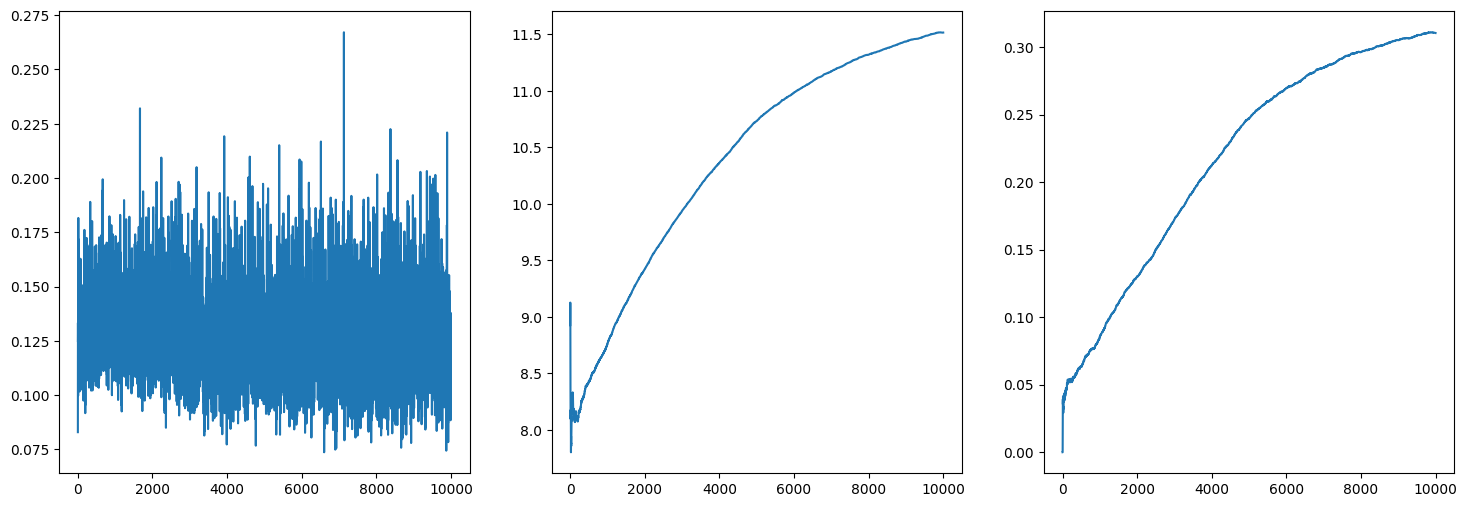

Mean game length: 8.15974547890154
Mean apples eaten: 0.21332886805090423
Max game length: 134
Max apples eaten: 14


(array([  4., 896.,  42.,  20.,  13.,  11.,   8.,   2.,   2.,   2.]),
 array([  7. ,  19.7,  32.4,  45.1,  57.8,  70.5,  83.2,  95.9, 108.6,
        121.3, 134. ]),
 <BarContainer object of 10 artists>)

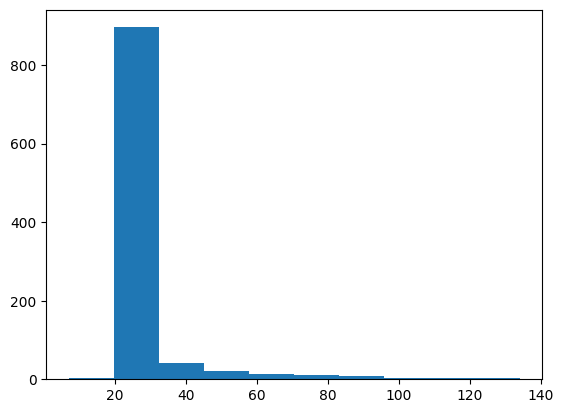

In [25]:
dqn_v1 = DeepQLearningAlgorithmV1(10, 0.002)
dqn_v1.fit(epochs=10000, epsilon_discount=0.9995)
dqn_v1.plot_loss()

dqn_v1.game.reset_aggregate_analytics()
lengths = []
for i in range(1000):
    lengths.append(dqn_v1.predict(output_grid=False))
print(f"Mean game length: {dqn_v1.game.total_length / dqn_v1.game.num_games}")
print(f"Mean apples eaten: {dqn_v1.game.total_apples_eaten / dqn_v1.game.num_games}")
print(f"Max game length: {dqn_v1.game.max_game_len}")
print(f"Max apples eaten: {dqn_v1.game.max_apples_eaten}")
plt.hist(lengths)

## A few observations about V1

We can note a few things from V1 which will carry over to the next algorithms:
- it's visible that the majority of games stop at 20 moves exactly. For 10x10 games, that is the limit the snake can go without getting an apple. We will see this spike with the other algorithms too.
- we can see that we track the mean apples eaten per game, and mean game lengths. When training the model, I decided to train until I could see the model starting to plateau on these metrics (and then shave off a few epochs because these take a while to train).
- the loss is stable, in fact it even looks like it's increasing. This is normal and expected. We slowly decrease $\epsilon$ with each iteration, so the agent increasingly relies on its own judgement, which of course takes time to train, and during which the agent's error increases. We do not expect the loss to decrease with more epochs, maybe stabilize, and if it does we have likely overfit the network.

## V2 (larger state)

We can make some obvious improvements to V1. First, we can add some information to the state to help guide the snake. We add its current direction and the value of the square in that direction. These will provide essential context which the network can use to avoid walls and its own tail. To compensate for the additional information, we add more neurons to the network to store more information.

Another important observation: the rewards in V1 were highly asymmetric. We were penalizing a move away from the apple much more than we were rewarding a step towards it, so the snake was being trained to just step rather than step towards the apple. Seems counterintuitive but relatively speaking, the 0.01 reward was not strong enough to guide the agent. This has been adjusted in V2.

Note from the future: this version of the algorithm ended up working significantly better. To try an extract some performance out of it, I tried the following parameter sets:

```
Params(0.0001, 10000, 0.9996, 4096, 1000, 10000),
Params(0.00005, 10000, 0.9996, 4096, 1000, 10000),
Params(0.0001, 15000, 0.9996, 4096, 1000, 10000),
Params(0.0001, 10000, 0.9996, 4096, 1000, 1000),
Params(0.0001, 10000, 0.9996, 10000, 1000, 10000),
Params(0.0001, 10000, 0.9995, 4096, 1000, 10000),
Params(0.0005, 10000, 0.9996, 4096, 1000, 10000),
Params(0.0001, 10000, 0.9996, 4096, 1000, 100000),
Params(0.0001, 10000, 0.9996, 4096, 500, 10000),
Params(0.0001, 10000, 0.9996, 4096, 2000, 10000),
Params(0.0001, 6667, 0.9996, 4096, 1000, 10000),
Params(0.0001, 20000, 0.9995, 4096, 5000, 10000),
Params(0.0001, 30000, 0.9995, 4096, 5000, 10000),
Params(0.0001, 50000, 0.9995, 4096, 5000, 10000),
Params(0.0001, 50000, 0.9995, 4096, 10000, 10000),
Params(0.0001, 50000, 0.99965, 4096, 10000, 10000),
Params(0.0001, 100000, 0.9997, 4096, 20000, 10000),
Params(0.0001, 200000, 0.9998, 4096, 40000, 10000),
Params(0.0001, 50000, 0.99965, 4096, 15000, 10000),
```

The best ones are in the code below. There is one other notable change: we switched to minibatch gradient descent for faster running on more epochs. This had the effect of much bigger gradient updates on each step, meaning the learning rate had to be much smaller. We also needed to make the initial content of the replay buffer much bigger, so that sampling 128 states at a time doesn't result in a bias towards samples where all the squares near to the snake are empty (0).

In [26]:
Params = namedtuple('ParamSet', ['lr', 'epochs', 'epsilon_discount', 'num_runs_before_replay', 'num_epochs_before_copy', 'buffer_size'])

In [27]:
class SnakeGameV2(SnakeGame):
    
    def _get_reward(self, current_state: np.ndarray, action: int, death: bool = False, apple: bool = False, steps_exceeded: bool = False) -> int:
        if apple:
            return 1
        elif death or steps_exceeded:
            return -1
        new_head = Point(
            self.snake[0].x + self.ACTIONS[action][0], 
            self.snake[0].y + self.ACTIONS[action][1]
        )
        old_apple_dist = abs(self.apple.x - self.snake[0].x) + abs(self.apple.y - self.snake[0].y)
        new_apple_dist = abs(self.apple.x - new_head.x) + abs(self.apple.y - new_head.y)
        if old_apple_dist <= new_apple_dist:
            return -0.2
        return 0.1

    def get_current_state(self) -> np.ndarray:
        current_action = self.prev_action or 0.0
        one_move_out = [Point(self.snake[0].x + dx, self.snake[0].y + dy) for (dx, dy) in self.ACTIONS]
        lookahead = Point(self.snake[0].x + 2 * self.ACTIONS[int(current_action)][0], self.snake[0].y + 2 * self.ACTIONS[int(current_action)][1])
        
        return np.array([
            *[self.grid[p.x][p.y] for p in one_move_out],
            abs(self.snake[0].x - self.apple.x) / self.n, 
            abs(self.snake[0].y - self.apple.y) / self.n,
            current_action / len(self.ACTIONS),
            self.grid[lookahead.x][lookahead.y] if (lookahead.x >= 0 and lookahead.x < self.n and lookahead.y >= 0 and lookahead.y < self.n) else -1.0
        ], dtype=np.float32)

In [28]:
class DeepQLearningAlgorithmV2(torch.nn.Module):
    def __init__(self, game_size: int, lr: float, buffer_size: int):
        super().__init__()
        self.online_network: torch.nn.Sequential = self._get_new_network()
        self.target_network: torch.nn.Sequential = copy.deepcopy(self.online_network)
        self.replay_buffer: deque[GameStep] = deque(maxlen=buffer_size)
        self.game: SnakeGameV2 = SnakeGameV2(game_size)
        self.loss_fn: torch.nn.MSELoss = torch.nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.online_network.parameters(), lr=lr)
        self.avg_losses = []
        self.avg_game_lengths = []
        self.avg_apples_eaten = []
    
    def _get_new_network(self) -> torch.nn.Sequential:
        return torch.nn.Sequential(
            torch.nn.Linear(8, 160),
            torch.nn.ReLU(),
            torch.nn.Linear(160, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 4),
        )
    
    def fit(self, epochs=1000, num_runs_before_replay=128, epoch_size=128, num_epochs_before_copy=10, discount=0.99, epsilon=1.0, epsilon_discount=0.995):
        for _ in range(num_runs_before_replay):
            action = randint(0, len(self.game.ACTIONS) - 1)
            result = self.game.execute_action(action)
            self.replay_buffer.append(result)
        
        with tqdm(total=epochs) as pbar:
            for epoch in range(epochs):
                losses = []
                for _ in range(epoch_size):
                    action = torch.argmax(self.online_network(torch.tensor(self.game.get_current_state(), dtype=torch.float32)))
                    if uniform(0, 1) < epsilon:
                        action = randint(0, len(self.game.ACTIONS) - 1)
                    result = self.game.execute_action(action)
                    self.replay_buffer.append(result)

                examples = sample(self.replay_buffer, 128)
                current_state_tensor = torch.tensor(np.asarray([s for (s, _, _, _) in examples]), dtype=torch.float32)
                action_tensor = torch.tensor(np.asarray([a for (_, a, _, _) in examples]), dtype=torch.int)
                reward_tensor = torch.tensor(np.asarray([r for (_, _, r, _) in examples]), dtype=torch.float32)
                next_state_tensor = torch.tensor(np.asarray([s2 for (_, _, _, s2) in examples]), dtype=torch.float32)

                target_output = self.target_network(next_state_tensor)
                (target_value, _) = torch.max(target_output, dim=1)
                no_discount = torch.where(reward_tensor >= -0.5, 1, 0)
                target_bellman = (reward_tensor + (torch.tensor(discount) * target_value * no_discount)).detach()
                example_action = self.online_network(current_state_tensor)[torch.arange(128), action_tensor]

                loss = self.loss_fn(example_action, target_bellman)
                losses.append(loss)
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                if epsilon > 0.1:
                    epsilon *= epsilon_discount
                pbar.set_postfix(
                    loss=f"{loss.tolist():.4f}", 
                    epsilon=f"{epsilon:.4f}", 
                    mean_game_length=f"{self.game.total_length / self.game.num_games:.4f}",
                    mean_apples_eaten=f"{self.game.total_apples_eaten / self.game.num_games:.4f}"
                )
                
                pbar.update(1)
                self.avg_losses.append(torch.mean(torch.tensor(losses)).tolist())
                self.avg_game_lengths.append(self.game.total_length / self.game.num_games)
                self.avg_apples_eaten.append(self.game.total_apples_eaten / self.game.num_games)

                if not epoch % num_epochs_before_copy:
                    self.target_network = copy.deepcopy(self.online_network)
    
    def plot_loss(self, title=""):
        f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
        ax1.plot(np.array(self.avg_losses))
        ax2.plot(np.array(self.avg_game_lengths))
        ax3.plot(np.array(self.avg_apples_eaten))
        plt.title(title)
        plt.show()
    
    def predict(self, output_grid=False):
        self.game._initialize_game()
        (s, a, r, s2) = (None, None, None, None)
        game_length = 0
        if output_grid:
            self.game._pretty_print_grid()
        while r != -1:
            action = torch.argmax(self.online_network(torch.tensor(self.game.get_current_state(), dtype=torch.float32)))
            (s, a, r, s2) = self.game.execute_action(action)
            game_length += 1
            if output_grid:
                self.game._pretty_print_grid()
        if output_grid:
            print("Game length:", game_length)
        return game_length

100%|██████████| 50000/50000 [17:51<00:00, 46.68it/s, epsilon=0.1000, loss=0.1112, mean_apples_eaten=1.1907, mean_game_length=18.6941]


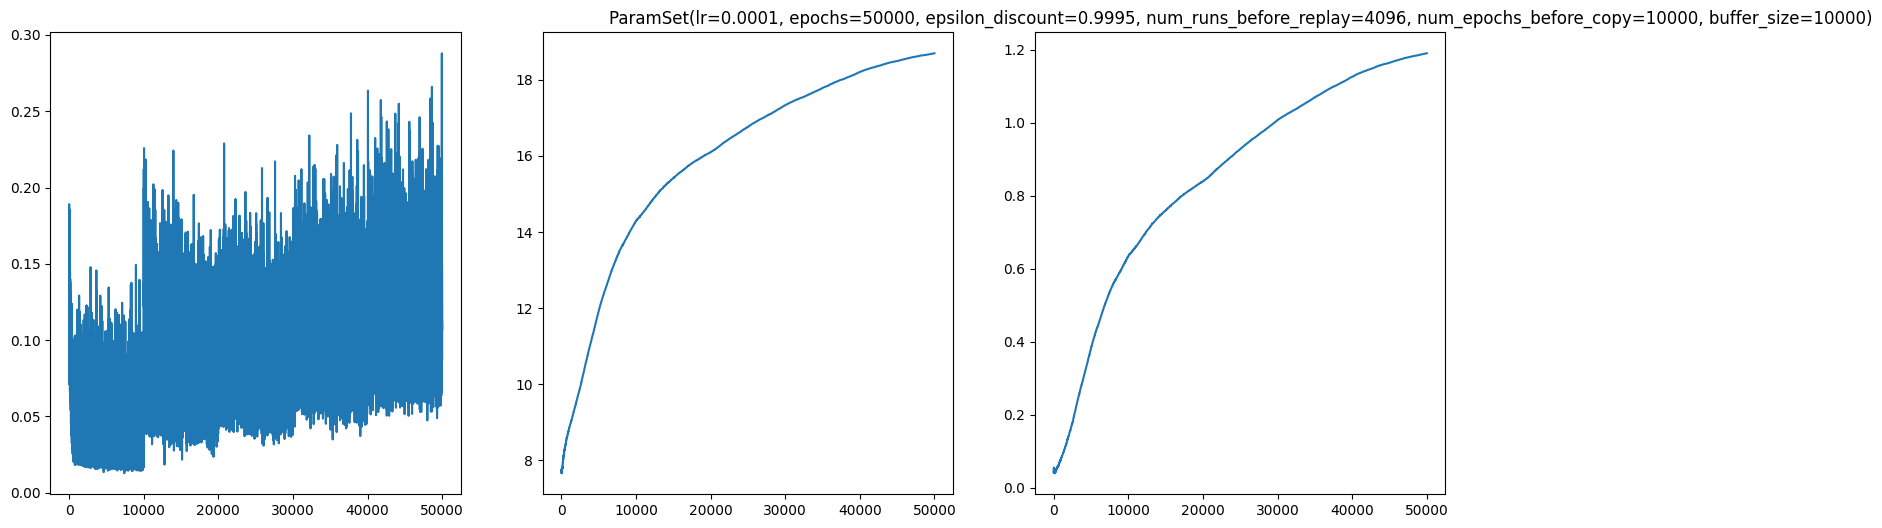

Mean game length: 23.224255471833512
Mean apples eaten: 1.97918909221385
Max game length: 232
Max apples eaten: 20


(array([27., 10., 26., 31., 39., 26., 34., 33., 46., 15., 14., 30., 33.,
        22., 12., 37., 36., 22., 28., 31., 19., 25., 17., 17., 16., 30.,
        20., 12., 16., 12., 20., 20., 11., 17., 12., 15., 10., 15., 14.,
         6., 11., 16., 12.,  3.,  5.,  6.,  8.,  6.,  4.,  4.,  7.,  7.,
         2.,  5.,  3.,  2.,  2.,  0.,  5.,  2.,  1.,  0.,  0.,  1.,  0.,
         2.,  1.,  1.,  1.,  0.,  0.,  0.,  0.,  2.,  0.,  0.,  0.,  3.,
         1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([ 20.  ,  22.12,  24.24,  26.36,  28.48,  30.6 ,  32.72,  34.84,
         36.96,  39.08,  41.2 ,  43.32,  45.44,  47.56,  49.68,  51.8 ,
         53.92,  56.04,  58.16,  60.28,  62.4 ,  64.52,  66.64,  68.76,
         70.88,  73.  ,  75.12,  77.24,  79.36,  81.48,  83.6 ,  85.72,
         87.84,  89.96,  92.08,  94.2 ,  96.32,  98.44, 100.56, 102.68,
        104.8 , 106.92, 109.04, 111.16, 113.28, 115.4 , 117.52, 119.64,
  

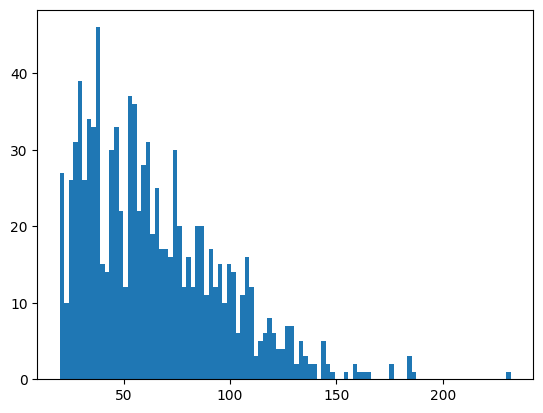

In [29]:
param_set = Params(0.0001, 50000, 0.9995, 4096, 10000, 10000)

dqn_v2 = DeepQLearningAlgorithmV2(10, param_set.lr, param_set.buffer_size)
dqn_v2.fit(epochs=param_set.epochs, epsilon_discount=param_set.epsilon_discount, num_runs_before_replay=param_set.num_runs_before_replay, num_epochs_before_copy=param_set.num_epochs_before_copy)
dqn_v2.plot_loss(title=param_set)
dqn_v2.game.reset_aggregate_analytics()
lengths = []
for i in range(1000):
    lengths.append(dqn_v2.predict(output_grid=False))
print(f"Mean game length: {dqn_v2.game.total_length / dqn_v2.game.num_games}")
print(f"Mean apples eaten: {dqn_v2.game.total_apples_eaten / dqn_v2.game.num_games}")
print(f"Max game length: {dqn_v2.game.max_game_len}")
print(f"Max apples eaten: {dqn_v2.game.max_apples_eaten}")
plt.hist(lengths, bins=100)

## V3 (full board view)

There are still some obvious limitations with not letting the agent see the full snake. For example, when a human plays the snak game, they can see the whole snake and avoid the tail. We can replicate this by building a network which feeds the full board to the network. For this, we will use a CNN. To make the features really clear to this network, we put the walls, snake, and apple each in their own channel. This representation is sparse, but allows the network to learn individually about all 3 aspects of the board.

Note from the future: this version of the algorithm ended up working significantly worse than the previous one, despite better scores in training. To try an extract some performance out of it, I tried the following parameter sets:

```
Params(0.0001, 10000, 0.9996, 4096, 1000, 10000),
Params(0.00005, 10000, 0.9996, 4096, 1000, 10000),
Params(0.0001, 15000, 0.9996, 4096, 1000, 10000),
Params(0.0001, 10000, 0.9996, 4096, 1000, 1000),
Params(0.0001, 10000, 0.9996, 10000, 1000, 10000),
Params(0.0001, 10000, 0.9995, 4096, 1000, 10000),
Params(0.0005, 10000, 0.9996, 4096, 1000, 10000),
Params(0.0001, 10000, 0.9996, 4096, 1000, 100000),
Params(0.0001, 10000, 0.9996, 4096, 500, 10000),
Params(0.0001, 10000, 0.9996, 4096, 2000, 10000),
Params(0.0001, 6667, 0.9996, 4096, 1000, 10000),
Params(0.0001, 20000, 0.9995, 4096, 5000, 10000),
Para3s(0.0001, 30000, 0.9995, 4096, 5000, 10000),
Params(0.0001, 50000, 0.9995, 4096, 5000, 10000),
Params(0.0001, 50000, 0.9995, 4096, 10000, 10000),
Params(0.0001, 50000, 0.99965, 4096, 10000, 10000),
Params(0.0001, 100000, 0.9997, 4096, 20000, 10000),
Params(0.0001, 200000, 0.9998, 4096, 40000, 10000),
Params(0.0001, 200000, 0.9995, 4096, 10000, 100000),
Params(0.0001, 50000, 0.99965, 4096, 15000, 10000),
```

The best ones are in the code below, but V2 worked best still. Note that the essential parameters for this version were the buffer size (because we needed more examples to train the network on) and the eopch size (to allow deep exploration through repeated sampling. CNN weights take much longer to tune).

In [35]:
class SnakeGameV3(SnakeGame):
    
    def _get_reward(self, current_state: np.ndarray, action: int, death: bool = False, apple: bool = False, steps_exceeded: bool = False) -> int:
        if apple:
            return 1
        elif death or steps_exceeded:
            return -1
        new_head = Point(
            self.snake[0].x + self.ACTIONS[action][0], 
            self.snake[0].y + self.ACTIONS[action][1]
        )
        old_apple_dist = abs(self.apple.x - self.snake[0].x) + abs(self.apple.y - self.snake[0].y)
        new_apple_dist = abs(self.apple.x - new_head.x) + abs(self.apple.y - new_head.y)
        if old_apple_dist <= new_apple_dist:
            return -0.2
        return 0.1

    def get_current_state(self) -> np.ndarray: 
        np_grid = np.array(self.grid)
        x = np.linspace(0, self.n, self.n, dtype=np.int32, endpoint=False)
        y = np.linspace(0, self.n, self.n, dtype=np.int32, endpoint=False)
        xv, yv = np.meshgrid(x, y)
        apple_layer = np.where(np_grid == 1, 1.0, 0.0)
        wall_layer = np.where(
            (xv == 0) | 
            (xv == self.n - 1) | 
            (yv == self.n - 1) | 
            (yv == 0), 1.0, 0.0
        )
        snake_layer = np.zeros(shape=(self.n, self.n))
        for p in self.snake:
            snake_layer[p.x][p.y] = 1.0
        return np.concatenate([
            apple_layer.reshape(1, self.n, self.n), 
            wall_layer.reshape(1, self.n, self.n), 
            snake_layer.reshape(1, self.n, self.n)
        ], axis=0)

In [38]:
class DeepQLearningAlgorithmV3(torch.nn.Module):
    def __init__(self, game_size: int, lr: float, buffer_size: int):
        super().__init__()
        self.online_network: torch.nn.Sequential = self._get_new_network()
        self.target_network: torch.nn.Sequential = copy.deepcopy(self.online_network)
        self.replay_buffer: deque[GameStep] = deque(maxlen=buffer_size)
        self.game: SnakeGameV3 = SnakeGameV3(game_size)
        self.loss_fn: torch.nn.MSELoss = torch.nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.online_network.parameters(), lr=lr)
        self.avg_losses = []
        self.avg_game_lengths = []
        self.avg_apples_eaten = []
        self.fc1 = torch.nn.Linear(64, 256)
        self.fc15 = torch.nn.Linear(256, 64)
        self.fc2 = torch.nn.Linear(64, 4)
        self.fc3 = copy.deepcopy(self.fc1)
        self.fc35 = copy.deepcopy(self.fc15)
        self.fc4 = copy.deepcopy(self.fc2)
    
    def _get_new_network(self) -> torch.nn.Sequential:
        return torch.nn.Sequential(
            torch.nn.Conv2d(3, 16, 3),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, 2),
            torch.nn.Conv2d(16, 64, 3),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(2, 2),
        )
    
    def forward_online(self, x, train=True):
        x = self.online_network(x.view(-1, 3, 10, 10))
        x = x.view(-1, 64)
        x = torch.nn.functional.relu(self.fc1(x))
        x = torch.nn.functional.relu(self.fc15(x))
        return self.fc2(x)
    
    def forward_target(self, x, train=True):
        x = self.target_network(x.view(-1, 3, 10, 10))
        x = x.view(-1, 64)
        x = torch.nn.functional.relu(self.fc3(x))
        x = torch.nn.functional.relu(self.fc35(x))
        return self.fc4(x)
    
    def fit(self, epochs=1000, num_runs_before_replay=128, epoch_size=128, num_epochs_before_copy=10, discount=0.99, epsilon=1.0, epsilon_discount=0.995):
        for _ in range(num_runs_before_replay):
            action = randint(0, len(self.game.ACTIONS) - 1)
            result = self.game.execute_action(action)
            self.replay_buffer.append(result)
        
        with tqdm(total=epochs) as pbar:
            for epoch in range(epochs):
                losses = []
                for _ in range(epoch_size):
                    state = self.game.get_current_state()
                    action = torch.argmax(self.forward_online(torch.tensor(state, dtype=torch.float32).reshape(1, 3, 10, 10)))
                    if uniform(0, 1) < epsilon:
                        action = randint(0, len(self.game.ACTIONS) - 1)
                    result = self.game.execute_action(action)
                    self.replay_buffer.append(result)

                examples = sample(self.replay_buffer, 128)
                current_state_tensor = torch.tensor(np.asarray([s for (s, _, _, _) in examples]), dtype=torch.float32)
                action_tensor = torch.tensor(np.asarray([a for (_, a, _, _) in examples]), dtype=torch.int)
                reward_tensor = torch.tensor(np.asarray([r for (_, _, r, _) in examples]), dtype=torch.float32)
                next_state_tensor = torch.tensor(np.asarray([s2 for (_, _, _, s2) in examples]), dtype=torch.float32)

                target_output = self.forward_target(next_state_tensor)
                (target_value, _) = torch.max(target_output, dim=1)
                no_discount = torch.where(reward_tensor >= -0.5, 1, 0)
                target_bellman = (reward_tensor + (torch.tensor(discount) * target_value * no_discount)).detach()
                example_action = self.forward_online(current_state_tensor)[torch.arange(128), action_tensor]

                loss = self.loss_fn(example_action, target_bellman)
                losses.append(loss)
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                if epsilon > 0.1:
                    epsilon *= epsilon_discount
                pbar.set_postfix(
                    loss=f"{loss.tolist():.4f}", 
                    epsilon=f"{epsilon:.4f}", 
                    mean_game_length=f"{self.game.total_length / self.game.num_games:.4f}",
                    mean_apples_eaten=f"{self.game.total_apples_eaten / self.game.num_games:.4f}"
                )
                
                pbar.update(1)
                self.avg_losses.append(torch.mean(torch.tensor(losses)).tolist())
                self.avg_game_lengths.append(self.game.total_length / self.game.num_games)
                self.avg_apples_eaten.append(self.game.total_apples_eaten / self.game.num_games)

                if not epoch % num_epochs_before_copy:
                    self.target_network = copy.deepcopy(self.online_network)
                    self.fc3 = copy.deepcopy(self.fc1)
                    self.fc35 = copy.deepcopy(self.fc15)
                    self.fc4 = copy.deepcopy(self.fc2)
    
    def plot_loss(self, title=""):
        f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
        ax1.plot(np.array(self.avg_losses))
        ax2.plot(np.array(self.avg_game_lengths))
        ax3.plot(np.array(self.avg_apples_eaten))
        plt.title(title)
        plt.show()
    
    def predict(self, output_grid=False):
        self.game._initialize_game()
        (s, a, r, s2) = (None, None, None, None)
        game_length = 0
        if output_grid:
            self.game._pretty_print_grid()
        while r != -1:
            action = torch.argmax(self.forward_online(torch.tensor(self.game.get_current_state(), dtype=torch.float32), train=False))
            (s, a, r, s2) = self.game.execute_action(action)
            game_length += 1
            if output_grid:
                self.game._pretty_print_grid()
        if output_grid:
            print("Game length:", game_length)
        return game_length

100%|██████████| 200000/200000 [8:19:26<00:00,  6.67it/s, epsilon=0.1000, loss=0.2465, mean_apples_eaten=2.5551, mean_game_length=20.4708]      


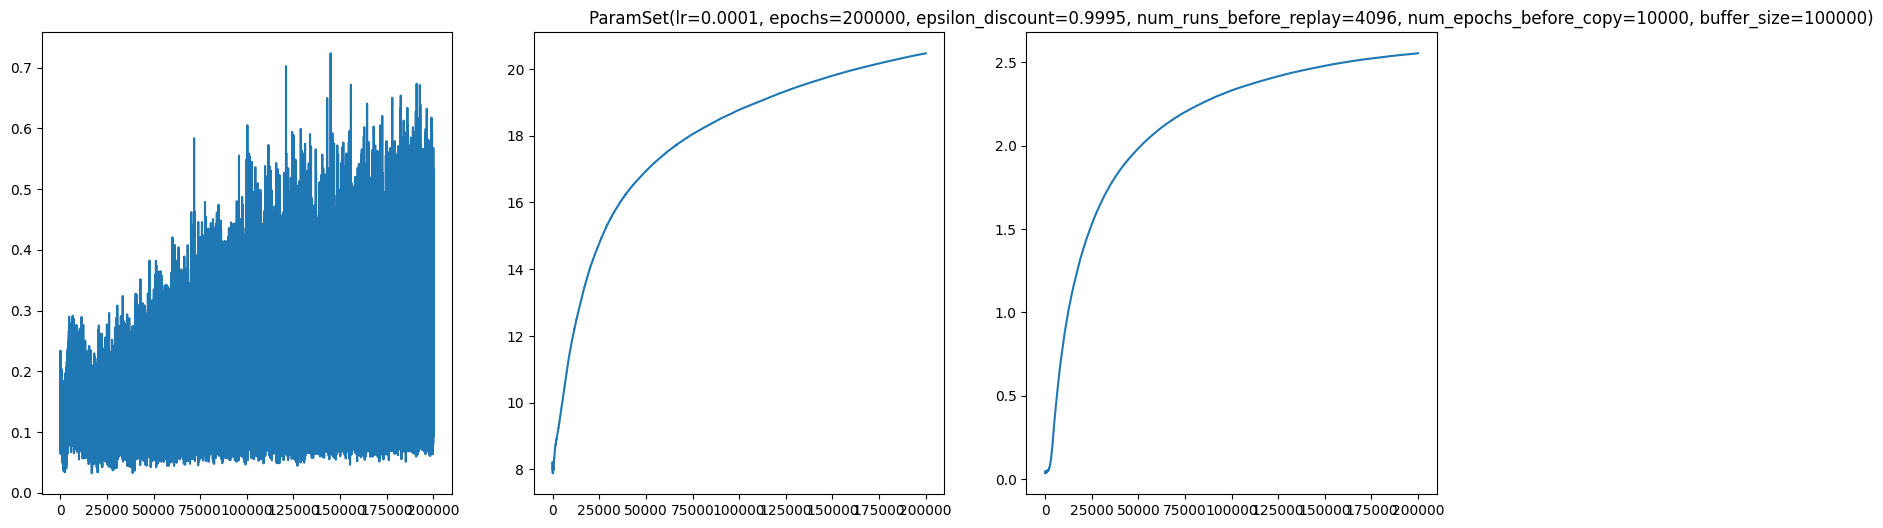

Mean game length: 16.336320754716983
Mean apples eaten: 2.082547169811321
Max game length: 103
Max apples eaten: 12


(array([ 5.,  3.,  4.,  9.,  9.,  7., 19., 16., 18., 11., 14., 20., 17.,
        22., 19., 50., 25., 23., 24., 11., 19., 21., 22., 17., 23., 20.,
        25., 24., 20., 22., 27., 29., 21., 20., 14., 27., 19., 16., 16.,
        14., 16., 14., 11., 13., 15., 11., 13.,  8., 15.,  0., 14., 15.,
         7.,  6., 10.,  8.,  4.,  6., 10.,  3.,  5.,  2.,  4.,  2.,  5.,
         1.,  3.,  4.,  1.,  0.,  2.,  2.,  6.,  3.,  0.,  1.,  3.,  2.,
         1.,  1.,  1.,  0.,  1.,  3.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  1.,  0.,  0.,  0.,  0.,  0.,  1.,  2.]),
 array([  5.  ,   5.98,   6.96,   7.94,   8.92,   9.9 ,  10.88,  11.86,
         12.84,  13.82,  14.8 ,  15.78,  16.76,  17.74,  18.72,  19.7 ,
         20.68,  21.66,  22.64,  23.62,  24.6 ,  25.58,  26.56,  27.54,
         28.52,  29.5 ,  30.48,  31.46,  32.44,  33.42,  34.4 ,  35.38,
         36.36,  37.34,  38.32,  39.3 ,  40.28,  41.26,  42.24,  43.22,
         44.2 ,  45.18,  46.16,  47.14,  48.12,  49.1 ,  50.08,  51.06,
  

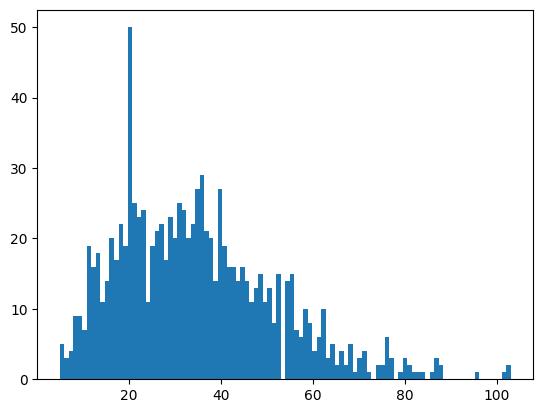

In [39]:
param_set = Params(0.0001, 200000, 0.9995, 4096, 10000, 100000)

dqn_v3 = DeepQLearningAlgorithmV3(10, param_set.lr, param_set.buffer_size)
dqn_v3.fit(epochs=param_set.epochs, epsilon_discount=param_set.epsilon_discount, num_runs_before_replay=param_set.num_runs_before_replay, num_epochs_before_copy=param_set.num_epochs_before_copy)
dqn_v3.plot_loss(title=param_set)
dqn_v3.game.reset_aggregate_analytics()
lengths = []
for i in range(1000):
    lengths.append(dqn_v3.predict(output_grid=False))
print(f"Mean game length: {dqn_v3.game.total_length / dqn_v3.game.num_games}")
print(f"Mean apples eaten: {dqn_v3.game.total_apples_eaten / dqn_v3.game.num_games}")
print(f"Max game length: {dqn_v3.game.max_game_len}")
print(f"Max apples eaten: {dqn_v3.game.max_apples_eaten}")
plt.hist(lengths, bins=100)

## Conclusion

Snake is not super well-suited for DQN. While it works well enough, it may be better to use an algorithm which can look further into the future and better understand how to have the snake avoid its tail, for example a Monte Carlo tree search. There are 3 likely issues with these implementations:
- the learning rate isn't being annealed, which is causing the plateaus we were observing later in learning
- $\epsilon$ is not being annealed properly either, the annealing should be proportional to the gain in our mean apples eaten
- sampling, especially later on in the game, should be done based on the length of the snake (sample more game states where the snake is longer). This is mostly important for V3, which has a full view of the board, because it likely will have only seen games where the snake is small, and CNNs generally need mroe epochs to train.

While the first 2 are easy issues to solve, they would not have much impact. All 3 versions of the model, even if they could have games where they could perform well, struggled to move the snake once it was relatively long. This is because of the very low frequency of games which last very long in training. We can see that mean game length during training barely broke 20, which is the amount of moves before the game terminate if an apple isn't eaten. Mean apples per game in training didn't make to 3, so we can assume the games played were very short. This can only really be solved by training more and lowering the learning rate, or by having a priority-based buffer which will gradually accumulate samples where the snake was larger and serve those with priority (which can lead to bias, and is therefore not such a great idea).But alas, I can only train these models so many times (they take hours). So, we will try some new algorithms in the next article!

Below you can see the best game I could get out of each of the models. Until next time!

In [40]:
print("abhij2706.github.io:start#slider")
dqn_v1.game.reset_aggregate_analytics()
dqn_v1.predict(output_grid=True)
print("abhij2706.github.io:end#slider")

abhij2706.github.io:start#slider
abhij2706.github.io:frame#start
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️🔴⬜️
⬜️⬛️⬛️⬛️✅⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
abhij2706.github.io:frame#end
abhij2706.github.io:frame#start
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️✅⬛️⬛️⬛️🔴⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
abhij2706.github.io:frame#end
abhij2706.github.io:frame#start
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️✅⬛️⬛️🔴⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
abhij2706.github.io:frame#end
abhij2706.github.io:frame#start
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️✅⬛️🔴⬜️
⬜

In [324]:
print("abhij2706.github.io:start#slider")
dqn_v2.game.reset_aggregate_analytics()
dqn_v2.predict(output_grid=True)
print("abhij2706.github.io:end#slider")

abhij2706.github.io:start#slider
abhij2706.github.io:frame#start
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️🔴⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️✅⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
abhij2706.github.io:frame#end
abhij2706.github.io:frame#start
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️🔴⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️✅⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
abhij2706.github.io:frame#end
abhij2706.github.io:frame#start
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️🔴⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️✅⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
abhij2706.github.io:frame#end
abhij2706.github.io:frame#start
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️🔴⬛️⬛️⬛️⬛️⬜️


In [329]:
print("abhij2706.github.io:start#slider")
dqn_v3.game.reset_aggregate_analytics()
dqn_v3.predict(output_grid=True)
print("abhij2706.github.io:end#slider")

abhij2706.github.io:start#slider
abhij2706.github.io:frame#start
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️✅⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️🔴⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
abhij2706.github.io:frame#end
abhij2706.github.io:frame#start
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️✅⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️🔴⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
abhij2706.github.io:frame#end
abhij2706.github.io:frame#start
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️✅⬛️🔴⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
abhij2706.github.io:frame#end
abhij2706.github.io:frame#start
⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬛️⬜️
⬜️⬛️⬛️⬛️⬛️⬛️⬛️✅🔴⬜️
⬜